In [1]:
# ══════════════════════════════════════════════════════════════════
# NB05 — Franchise Intelligence
# The Platform Shift: A Deep Dive
# ══════════════════════════════════════════════════════════════════
#
# Five title-level analyses that sit between publisher aggregates
# (NB03/NB04) and the predictive model (NB06):
#
#   Block 1 — Launch Quality Delta
#             First-30-day positive rate vs steady-state lifetime.
#             Positive delta = rough launch, recovered over time.
#             Negative delta = launch hype faded.
#
#   Block 2 — Playtime-Sentiment Correlation
#             Pearson r between author playtime and VADER compound.
#             Positive r = advocates deepen with investment.
#             Negative r = burnout signal (common in live service).
#
#   Block 3 — Franchise Fatigue
#             Sequential sentiment across franchise entries.
#             Identifies improving vs declining franchise arcs.
#
#   Block 4 — Language Distribution (title level)
#             Extends NB04 language analysis to individual titles.
#             Flags globalisation leaders and JP-market titles.
#
#   Block 5 — Review Volume HHI (concentration proxy)
#             Herfindahl index on review volume per publisher.
#             SteamSpy unavailable — review count used as proxy.
#             Flags franchise dependency risk.
#
# Inputs:
#   ../data/raw/reviews/*.json
#   ../data/processed/NB04_vader_scores.csv
#   ../data/processed/NB04_claude_themes.csv
#   ../data/processed/NB02_revenue_pivot.csv
#
# Outputs:
#   ../data/processed/NB05_timestamps.csv        (intermediate cache)
#   ../data/processed/NB05_launch_delta.csv
#   ../data/processed/NB05_playtime_sentiment.csv
#   ../data/processed/NB05_franchise_fatigue.csv
#   ../data/processed/NB05_language_dist.csv
#   ../data/processed/NB05_hhi.csv
#   ../data/processed/NB05_franchise_chart.png
#   ../data/processed/NB05_language_chart.png
#
# Notebook map:
#   Cell 1  — Config & imports
#   Cell 2  — Load inputs + timestamp lookup
#   Cell 3  — Block 1: Launch Quality Delta
#   Cell 4  — Block 2: Playtime-Sentiment Correlation
#   Cell 5  — Block 3: Franchise Fatigue
#   Cell 6  — Block 4: Language Distribution
#   Cell 7  — Block 5: Review Volume HHI
#   Cell 8  — Visualization (4-panel franchise chart)
#   Cell 9  — Visualization (language distribution chart)
#   Cell 10 — Save outputs
#   Cell 11 — NB05 Observation
# ══════════════════════════════════════════════════════════════════

# ── CELL 1: Config ────────────────────────────────────────────────
USE_CACHE            = True
LAUNCH_WINDOW_DAYS   = 30    # days post-release = launch window
MIN_LAUNCH_REVIEWS   = 10    # minimum reviews in window to include title
MIN_PLAYTIME_REVIEWS = 50    # minimum reviews for playtime-sentiment r
PLAYTIME_CAP_PCT     = 99    # cap playtime outliers at this percentile

import sys
import json
import warnings
import importlib
from pathlib import Path
warnings.filterwarnings('ignore')

_cwd = Path('.').resolve()
if (_cwd / 'extractors').exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'extractors').exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
RAW_REVIEWS  = PROJECT_ROOT / 'data' / 'raw' / 'reviews'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
sys.path.insert(0, str(PROJECT_ROOT / 'extractors'))
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties
_jp_fp = FontProperties(family='Noto Sans JP')

# JP font — Noto Sans JP confirmed available, matches Streamlit app.
# Font set AFTER plt.rcParams.update() to prevent Segoe UI override.
JP_FONT = 'Noto Sans JP'
EN_FONT = 'Plus Jakarta Sans'

plt.rcParams.update({
    'font.family':      JP_FONT,   # JP-capable default for all text
    'font.size':        10,
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#252836',
    'axes.edgecolor':   '#2D3148',
    'axes.labelcolor':  '#CCCCCC',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'text.color':       '#FFFFFF',
    'grid.color':       '#2D3148',
    'legend.facecolor': '#1F2937',
    'legend.edgecolor': '#374151',
})

PUBLISHER_COLORS = {
    'sie':          '#E8780A',
    'bandai_namco': '#C8A800',
    'sega_atlus':   '#4A90D9',
    'square_enix':  '#E4002B',
    'ea':           '#D63800',
    'take_two':     '#2B5BB5',
    'ubisoft':      '#6B7A8D',
}

DISPLAY_NAMES = {
    'sie':          'SIE',
    'bandai_namco': 'Bandai Namco',
    'sega_atlus':   'Sega/Atlus',
    'square_enix':  'Square Enix',
    'ea':           'EA',
    'take_two':     'Take-Two',
    'ubisoft':      'Ubisoft',
}

JP_TARGETS = ['sie', 'bandai_namco', 'sega_atlus', 'square_enix']
WESTERN    = ['ea', 'take_two', 'ubisoft']

# Franchise sequences — ordered by PC release date (chronological)
# JP targets first, western benchmarks for comparison at bottom
FRANCHISE_SEQUENCES = {
    # Sega/Atlus
    'Persona':            ['Persona 4 Golden', 'Persona 5 Royal', 'Persona 3 Reload'],
    'Like a Dragon':      ['Yakuza: Like a Dragon', 'Like a Dragon: Infinite Wealth'],
    'Sonic':              ['Sonic Frontiers', 'Sonic Superstars'],
    # Square Enix
    'NieR':               ['NieR: Automata', 'NieR Replicant'],
    'Final Fantasy VII':  ['Final Fantasy VII Remake Intergrade', 'Final Fantasy VII Rebirth'],
    'Octopath Traveler':  ['Octopath Traveler', 'Octopath Traveler II'],
    # Bandai Namco
    'Dragon Ball':        ['Dragon Ball FighterZ', 'Dragon Ball: Sparking! Zero'],
    # SIE
    'Horizon':            ['Horizon Zero Dawn', 'Horizon Forbidden West'],
    "Spider-Man":         ["Marvel's Spider-Man Remastered", "Marvel's Spider-Man: Miles Morales"],
    'God of War':         ['God of War (2018)', 'God of War Ragnar\u00f6k'],
    # Western benchmarks (comparison)
    "Assassin's Creed":   ["Assassin's Creed Mirage", "Assassin's Creed Shadows"],
    'EA Sports FC':       ['EA Sports FC 24', 'EA Sports FC 25'],
}

# Cache paths
TIMESTAMP_CACHE    = PROCESSED / 'NB05_timestamps.csv'
LAUNCH_DELTA_CACHE = PROCESSED / 'NB05_launch_delta.csv'

print('NB05 config loaded')
print(f'Franchise sequences defined: {len(FRANCHISE_SEQUENCES)}')
print(f'Total titles in sequences  : {sum(len(v) for v in FRANCHISE_SEQUENCES.values())}')


NB05 config loaded
Franchise sequences defined: 12
Total titles in sequences  : 25


In [2]:
# ── CELL 2: Load inputs + timestamp lookup ────────────────────────
import game_registry
importlib.reload(game_registry)
from game_registry import GAME_REGISTRY

# Build lookup maps
appid_to_publisher = {}
appid_to_title     = {}
appid_to_release   = {}
title_to_appid     = {}

for publisher, games in GAME_REGISTRY.items():
    for title, meta in games.items():
        aid = meta.get('appid')
        rpc = meta.get('release_pc')
        if aid:
            appid_to_publisher[int(aid)] = publisher
            appid_to_title[int(aid)]     = title
            title_to_appid[title]        = int(aid)
        if aid and rpc:
            try:
                appid_to_release[int(aid)] = pd.to_datetime(rpc)
            except Exception:
                pass

# Load VADER cache
vader_df = pd.read_csv(PROCESSED / 'NB04_vader_scores.csv')
vader_df['appid'] = vader_df['appid'].astype(int)
vader_df['recommendationid'] = vader_df['recommendationid'].astype(str)
print(f'VADER cache    : {len(vader_df):,} rows | '
      f'{vader_df["appid"].nunique()} titles')

# Load Claude cache
claude_df = pd.read_csv(PROCESSED / 'NB04_claude_themes.csv')
print(f'Claude cache   : {len(claude_df):,} rows')

# Load revenue CAGR
NB02_TO_NB01 = {
    'sony':         'sie',
    'bandai_namco': 'bandai_namco',
    'sega_sammy':   'sega_atlus',
    'square_enix':  'square_enix',
    'nintendo':     'nintendo',
    'ea':           'ea',
    'take_two':     'take_two',
    'ubisoft':      'ubisoft',
}
try:
    pivot_raw = pd.read_csv(PROCESSED / 'NB02_revenue_pivot.csv', index_col=0)
    pivot_raw.columns = [int(c) if str(c).isdigit() else c
                         for c in pivot_raw.columns]
    def calc_cagr(row, start, end):
        if start not in row.index or end not in row.index:
            return None
        try:
            vs, ve = float(row[start]), float(row[end])
        except (TypeError, ValueError):
            return None
        if pd.isna(vs) or pd.isna(ve) or vs <= 0:
            return None
        return round(((ve / vs) ** (1 / (end - start)) - 1) * 100, 1)
    cagr_map = {}
    for company, row in pivot_raw.iterrows():
        pg = NB02_TO_NB01.get(company, company)
        cagr_map[pg] = calc_cagr(row, 2022, 2025) or calc_cagr(row, 2022, 2024)
    print(f'Revenue CAGR   : loaded for {len(cagr_map)} publishers')
except Exception as e:
    cagr_map = {}
    print(f'Revenue CAGR   : not available ({e})')

# ── Build timestamp lookup from raw JSONs ─────────────────────────
# timestamp_created not in VADER cache — extract from source JSONs once
if USE_CACHE and TIMESTAMP_CACHE.exists():
    ts_df = pd.read_csv(TIMESTAMP_CACHE)
    ts_df['recommendationid'] = ts_df['recommendationid'].astype(str)
    print(f'Timestamp cache: {len(ts_df):,} rows (loaded)')
else:
    print('Building timestamp lookup from raw JSONs...')
    ts_rows = []
    for path in sorted(RAW_REVIEWS.glob('*.json')):
        with open(path) as f:
            d = json.load(f)
        for rev in d.get('reviews', []):
            rid = rev.get('recommendationid')
            ts  = rev.get('timestamp_created')
            if rid and ts:
                ts_rows.append({
                    'recommendationid': str(rid),
                    'timestamp_created': int(ts),
                })
    ts_df = pd.DataFrame(ts_rows)
    ts_df.to_csv(TIMESTAMP_CACHE, index=False)
    print(f'Timestamp cache: {len(ts_df):,} rows → saved')

# Merge timestamps into VADER df
vader_ts = vader_df.merge(ts_df, on='recommendationid', how='left')
n_with_ts = vader_ts['timestamp_created'].notna().sum()
print(f'VADER + ts     : {len(vader_ts):,} rows | '
      f'timestamp coverage {n_with_ts/len(vader_ts)*100:.1f}%')

# Attach release dates
vader_ts['release_pc'] = vader_ts['appid'].map(appid_to_release)
vader_ts['dt_created'] = pd.to_datetime(
    vader_ts['timestamp_created'], unit='s', errors='coerce'
)
vader_ts['days_since_release'] = (
    vader_ts['dt_created'] - vader_ts['release_pc']
).dt.days


VADER cache    : 228,776 rows | 46 titles
Claude cache   : 2,270 rows
Revenue CAGR   : loaded for 8 publishers
Timestamp cache: 229,681 rows (loaded)
VADER + ts     : 228,776 rows | timestamp coverage 100.0%


In [3]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 1 — Launch Quality Delta
# ══════════════════════════════════════════════════════════════════
# Compare positive review rate in first LAUNCH_WINDOW_DAYS days
# vs steady-state lifetime.
#
# delta = steady_pos_rate - launch_pos_rate
#   > 0 : rough launch, reputation improved over time
#   < 0 : strong launch, hype faded (or ongoing controversy)
#
# Caveat: Steam cursor paginates newest-first by default.
# 5k cap may undersample old launch windows for large titles.
# Flagged for NB07.
# ══════════════════════════════════════════════════════════════════

# ── CELL 3: Launch Quality Delta ──────────────────────────────────
if USE_CACHE and LAUNCH_DELTA_CACHE.exists():
    launch_df = pd.read_csv(LAUNCH_DELTA_CACHE)
    print(f'Launch delta cache loaded: {len(launch_df)} titles')
else:
    rows = []
    grp_cols = ['appid', 'title', 'publisher_group']
    for (appid, title, pub), grp in vader_ts.groupby(grp_cols):
        grp = grp.dropna(subset=['days_since_release', 'voted_up'])
        grp = grp[grp['days_since_release'] >= 0]  # exclude pre-release reviews

        launch = grp[grp['days_since_release'] <= LAUNCH_WINDOW_DAYS]
        steady = grp[grp['days_since_release'] >  LAUNCH_WINDOW_DAYS]

        if len(launch) < MIN_LAUNCH_REVIEWS or len(steady) < MIN_LAUNCH_REVIEWS:
            continue

        launch_pos = launch['voted_up'].astype(float).mean()
        steady_pos = steady['voted_up'].astype(float).mean()
        delta      = steady_pos - launch_pos   # positive = recovery

        rows.append({
            'appid':           int(appid),
            'title':           title,
            'publisher_group': pub,
            'launch_n':        len(launch),
            'steady_n':        len(steady),
            'launch_pos_rate': round(float(launch_pos), 4),
            'steady_pos_rate': round(float(steady_pos), 4),
            'launch_delta':    round(float(delta), 4),
        })

    launch_df = pd.DataFrame(rows).sort_values('launch_delta', ascending=False)
    launch_df.to_csv(LAUNCH_DELTA_CACHE, index=False)
    print(f'Computed launch delta for {len(launch_df)} titles → saved')

launch_df['display_pub'] = launch_df['publisher_group'].map(DISPLAY_NAMES)

# Publisher-level summary
pub_launch = (
    launch_df.groupby('publisher_group')
    .agg(
        titles           = ('title', 'count'),
        mean_delta       = ('launch_delta', 'mean'),
        n_recoveries     = ('launch_delta', lambda x: (x > 0.02).sum()),
        n_fades          = ('launch_delta', lambda x: (x < -0.02).sum()),
    )
    .round(3)
    .sort_values('mean_delta', ascending=False)
)
pub_launch['display_name'] = pub_launch.index.map(DISPLAY_NAMES)

print('\n── Launch Quality Delta: Publisher Summary ──────────────────')
print(pub_launch[['display_name','titles','mean_delta',
                   'n_recoveries','n_fades']].to_string())

print('\n── Top 5 Recoveries (rough launch → improved) ───────────────')
print(launch_df.head(5)[
    ['title','display_pub','launch_pos_rate','steady_pos_rate','launch_delta']
].to_string(index=False))

print('\n── Top 5 Fades (strong launch → hype didn\'t hold) ──────────')
print(launch_df.tail(5)[
    ['title','display_pub','launch_pos_rate','steady_pos_rate','launch_delta']
].to_string(index=False))


Launch delta cache loaded: 4 titles

── Launch Quality Delta: Publisher Summary ──────────────────
                 display_name  titles  mean_delta  n_recoveries  n_fades
publisher_group                                                         
square_enix       Square Enix       1       0.059             1        0
ubisoft               Ubisoft       1       0.059             1        0
sega_atlus         Sega/Atlus       1      -0.003             0        0
bandai_namco     Bandai Namco       1      -0.131             0        1

── Top 5 Recoveries (rough launch → improved) ───────────────
            title  display_pub  launch_pos_rate  steady_pos_rate  launch_delta
        Forspoken  Square Enix           0.6488           0.7077        0.0589
Star Wars Outlaws      Ubisoft           0.5517           0.6104        0.0587
 Sonic Superstars   Sega/Atlus           0.6877           0.6850       -0.0027
 Gundam Breaker 4 Bandai Namco           0.7760           0.6446       -0.1314

── T

In [4]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 2 — Playtime-Sentiment Correlation
# ══════════════════════════════════════════════════════════════════
# Pearson r between author_playtime_forever and vader_compound,
# computed per title (English reviews only — VADER reliable).
#
# Interpretation:
#   r > +0.10 : advocates deepen — more time = more positive
#   r < -0.10 : burnout signal — more time = more negative
#   |r| < 0.10: no meaningful playtime-sentiment relationship
#
# Playtime capped at PLAYTIME_CAP_PCT to exclude FF14-style
# outliers (100k+ hour players skew publisher averages).
# ══════════════════════════════════════════════════════════════════

# ── CELL 4: Playtime-Sentiment Correlation ────────────────────────
PLAYTIME_CACHE = PROCESSED / 'NB05_playtime_sentiment.csv'

if USE_CACHE and PLAYTIME_CACHE.exists():
    playtime_df = pd.read_csv(PLAYTIME_CACHE)
    print(f'Playtime cache loaded: {len(playtime_df)} titles')
else:
    # English reviews only — VADER compound meaningful only for English
    eng = vader_df[
        vader_df['language'] == 'english'
    ].copy()

    # Cap outlier playtime
    cap = np.percentile(
        eng['playtime_forever'].dropna(), PLAYTIME_CAP_PCT
    )
    eng = eng[eng['playtime_forever'] <= cap].copy()
    eng = eng[eng['playtime_forever'] > 0].copy()  # exclude 0-playtime reviews

    rows = []
    for (appid, title, pub), grp in eng.groupby(
        ['appid', 'title', 'publisher_group']
    ):
        if len(grp) < MIN_PLAYTIME_REVIEWS:
            continue
        x = grp['playtime_forever'].values
        y = grp['vader_compound'].values
        # Pearson r via numpy
        if np.std(x) == 0 or np.std(y) == 0:
            continue
        r = float(np.corrcoef(x, y)[0, 1])

        rows.append({
            'appid':            int(appid),
            'title':            title,
            'publisher_group':  pub,
            'n_reviews':        len(grp),
            'playtime_r':       round(r, 4),
            'median_playtime':  round(float(np.median(x)), 0),
            'signal': (
                'advocates_deepen' if r >  0.10 else
                'burnout_signal'   if r < -0.10 else
                'neutral'
            ),
        })

    playtime_df = pd.DataFrame(rows).sort_values('playtime_r', ascending=False)
    playtime_df.to_csv(PLAYTIME_CACHE, index=False)
    print(f'Playtime-sentiment computed: {len(playtime_df)} titles → saved')

playtime_df['display_pub'] = playtime_df['publisher_group'].map(DISPLAY_NAMES)

# Publisher-level summary
pub_playtime = (
    playtime_df.groupby('publisher_group')
    .agg(
        titles     = ('title', 'count'),
        mean_r     = ('playtime_r', 'mean'),
        n_deepen   = ('signal', lambda x: (x == 'advocates_deepen').sum()),
        n_burnout  = ('signal', lambda x: (x == 'burnout_signal').sum()),
    )
    .round(3)
    .sort_values('mean_r', ascending=False)
)
pub_playtime['display_name'] = pub_playtime.index.map(DISPLAY_NAMES)

print('── Playtime-Sentiment: Publisher Summary ────────────────────')
print(pub_playtime[['display_name','titles','mean_r',
                     'n_deepen','n_burnout']].to_string())

print('\n── Strongest advocate-deepening titles ──────────────────────')
print(playtime_df[playtime_df['signal']=='advocates_deepen'][
    ['title','display_pub','playtime_r','median_playtime','n_reviews']
].head(5).to_string(index=False))

print('\n── Strongest burnout signals ────────────────────────────────')
print(playtime_df[playtime_df['signal']=='burnout_signal'][
    ['title','display_pub','playtime_r','median_playtime','n_reviews']
].to_string(index=False))


Playtime cache loaded: 46 titles
── Playtime-Sentiment: Publisher Summary ────────────────────
                 display_name  titles  mean_r  n_deepen  n_burnout
publisher_group                                                   
ubisoft               Ubisoft       3   0.095         1          0
square_enix       Square Enix      11   0.094         4          0
sega_atlus         Sega/Atlus       8   0.074         1          0
bandai_namco     Bandai Namco       8   0.039         1          0
sie                       SIE      10   0.033         1          0
take_two             Take-Two       3  -0.004         0          0
ea                         EA       3  -0.007         0          0

── Strongest advocate-deepening titles ──────────────────────
                  title  display_pub  playtime_r  median_playtime  n_reviews
              Forspoken  Square Enix      0.1860           1681.0       2725
      Marvel's Avengers  Square Enix      0.1299           1086.0       1675
        

In [5]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 3 — Franchise Fatigue
# ══════════════════════════════════════════════════════════════════
# For each franchise sequence, compare VADER compound and
# positive review rate across sequential entries.
#
# fatigue_delta = last_entry_compound - first_entry_compound
#   > 0 : franchise improving / globalization arc (Persona playbook)
#   < 0 : franchise declining / sequel fatigue
#
# Entries ordered by PC release date from game_registry.
# ══════════════════════════════════════════════════════════════════

# ── CELL 5: Franchise Fatigue ─────────────────────────────────────
FATIGUE_CACHE = PROCESSED / 'NB05_franchise_fatigue.csv'

if USE_CACHE and FATIGUE_CACHE.exists():
    fatigue_df = pd.read_csv(FATIGUE_CACHE)
    print(f'Franchise fatigue cache loaded: {len(fatigue_df)} entries')
else:
    # Title-level VADER summary
    title_summary = (
        vader_df.groupby(['appid', 'title', 'publisher_group'])
        .agg(
            n_reviews     = ('vader_compound', 'count'),
            mean_compound = ('vader_compound', 'mean'),
            pct_positive  = ('voted_up',       'mean'),
        )
        .round(4)
        .reset_index()
    )

    rows = []
    for franchise, titles in FRANCHISE_SEQUENCES.items():
        # Sort by PC release date from registry
        titled_with_dates = []
        for t in titles:
            aid = title_to_appid.get(t)
            rel = appid_to_release.get(aid) if aid else None
            titled_with_dates.append((t, rel))
        # Sort chronologically, put None dates last
        titled_with_dates.sort(
            key=lambda x: x[1] if x[1] is not None else pd.Timestamp.max
        )

        for seq_idx, (title, rel_date) in enumerate(titled_with_dates):
            match = title_summary[title_summary['title'] == title]
            if match.empty:
                continue
            row  = match.iloc[0]
            rows.append({
                'franchise':       franchise,
                'seq_idx':         seq_idx,
                'title':           title,
                'publisher_group': row['publisher_group'],
                'release_pc':      str(rel_date)[:10] if rel_date else None,
                'n_reviews':       int(row['n_reviews']),
                'mean_compound':   float(row['mean_compound']),
                'pct_positive':    float(row['pct_positive']),
            })

    fatigue_df = pd.DataFrame(rows)
    fatigue_df.to_csv(FATIGUE_CACHE, index=False)
    print(f'Franchise fatigue: {len(fatigue_df)} entries across '
          f'{fatigue_df["franchise"].nunique()} franchises → saved')

fatigue_df['display_pub'] = fatigue_df['publisher_group'].map(DISPLAY_NAMES)

# Franchise-level delta (last - first entry)
franchise_deltas = []
for franchise, grp in fatigue_df.groupby('franchise'):
    grp = grp.sort_values('seq_idx')
    if len(grp) < 2:
        continue
    first = grp.iloc[0]
    last  = grp.iloc[-1]
    franchise_deltas.append({
        'franchise':       franchise,
        'publisher_group': first['publisher_group'],
        'n_entries':       len(grp),
        'first_title':     first['title'],
        'last_title':      last['title'],
        'first_compound':  first['mean_compound'],
        'last_compound':   last['mean_compound'],
        'fatigue_delta':   round(last['mean_compound'] - first['mean_compound'], 4),
    })

delta_df = pd.DataFrame(franchise_deltas).sort_values(
    'fatigue_delta', ascending=False
)
delta_df['display_pub'] = delta_df['publisher_group'].map(DISPLAY_NAMES)

print('── Franchise Arc Summary ────────────────────────────────────')
print('  fatigue_delta > 0 = improving arc | < 0 = declining arc')
print()
print(delta_df[[
    'franchise','display_pub','n_entries',
    'first_compound','last_compound','fatigue_delta'
]].to_string(index=False))


Franchise fatigue cache loaded: 25 entries
── Franchise Arc Summary ────────────────────────────────────
  fatigue_delta > 0 = improving arc | < 0 = declining arc

        franchise  display_pub  n_entries  first_compound  last_compound  fatigue_delta
    Like a Dragon   Sega/Atlus          2          0.2127         0.2763         0.0636
             NieR  Square Enix          2          0.1847         0.2289         0.0442
            Sonic   Sega/Atlus          2          0.2374         0.2712         0.0338
       God of War          SIE          2          0.1402         0.1666         0.0264
      Dragon Ball Bandai Namco          2          0.1544         0.1496        -0.0048
     EA Sports FC           EA          2          0.0916         0.0836        -0.0080
Final Fantasy VII  Square Enix          2          0.2105         0.2015        -0.0090
Octopath Traveler  Square Enix          2          0.2073         0.1913        -0.0160
       Spider-Man          SIE          2   

In [6]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 4 — Language Distribution (title level)
# ══════════════════════════════════════════════════════════════════
# Extends NB04 language analysis from publisher to title level.
# Identifies globalisation leaders and JP-market concentration.
# ══════════════════════════════════════════════════════════════════

# ── CELL 6: Language Distribution ────────────────────────────────
LANG_CACHE = PROCESSED / 'NB05_language_dist.csv'

if USE_CACHE and LANG_CACHE.exists():
    lang_df = pd.read_csv(LANG_CACHE)
    print(f'Language dist cache loaded: {len(lang_df)} rows')
else:
    lang_counts = (
        vader_df.groupby(['publisher_group', 'title', 'language'])
        .size()
        .reset_index(name='count')
    )
    totals = lang_counts.groupby(['publisher_group', 'title'])['count'].transform('sum')
    lang_counts['pct'] = (lang_counts['count'] / totals * 100).round(1)

    lang_df = lang_counts.copy()
    lang_df.to_csv(LANG_CACHE, index=False)
    print(f'Language dist: {len(lang_df)} rows → saved')

# Publisher-level: english share range
eng_by_title = lang_df[lang_df['language'] == 'english'].copy()
eng_by_title = eng_by_title.rename(columns={'pct': 'english_pct'})

pub_lang = (
    eng_by_title.groupby('publisher_group')['english_pct']
    .agg(['mean', 'min', 'max'])
    .round(1)
    .sort_values('mean', ascending=False)
)
pub_lang.index = pub_lang.index.map(DISPLAY_NAMES)

print('── English Share by Publisher (title-level range) ───────────')
print(pub_lang.rename(columns={
    'mean': 'avg_english_%',
    'min':  'min_english_%',
    'max':  'max_english_%',
}).to_string())

# Most globalised titles (highest english %)
print('\n── Most Globalised Titles (highest English share) ───────────')
print(eng_by_title.nlargest(8, 'english_pct')[
    ['title', 'publisher_group', 'english_pct']
].assign(pub=lambda df: df['publisher_group'].map(DISPLAY_NAMES))
 [['title', 'pub', 'english_pct']].to_string(index=False))

# Most JP-concentrated titles (lowest english %)
print('\n── Most JP-Concentrated Titles (lowest English share) ───────')
# Filter out titles with very few reviews for this analysis
title_totals = (
    lang_df.groupby('title')['count'].sum()
    .reset_index(name='total_reviews')
)
eng_filtered = eng_by_title.merge(title_totals, on='title')
eng_filtered = eng_filtered[eng_filtered['total_reviews'] >= 500]
print(eng_filtered.nsmallest(8, 'english_pct')[
    ['title', 'publisher_group', 'english_pct', 'total_reviews']
].assign(pub=lambda df: df['publisher_group'].map(DISPLAY_NAMES))
 [['title', 'pub', 'english_pct', 'total_reviews']].to_string(index=False))


Language dist cache loaded: 1268 rows
── English Share by Publisher (title-level range) ───────────
                 avg_english_%  min_english_%  max_english_%
publisher_group                                             
Ubisoft                   54.8           35.6           87.0
Sega/Atlus                48.2           32.2           73.2
SIE                       46.4           31.0           68.2
Square Enix               46.3           32.6           76.2
Bandai Namco              44.2           25.4           58.3
Take-Two                  38.2           26.6           49.8
EA                        29.6           23.7           38.4

── Most Globalised Titles (highest English share) ───────────
                      title          pub  english_pct
          Star Wars Outlaws      Ubisoft         87.0
   Final Fantasy XIV Online  Square Enix         76.2
           Sonic Superstars   Sega/Atlus         73.2
                   Returnal          SIE         68.2
               Hel

In [7]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 5 — Steam Recommendations HHI (concentration proxy)
# ══════════════════════════════════════════════════════════════════
# Herfindahl-Hirschman Index on Steam total recommendations per title.
#
# Source: data/raw/details/{appid}.json → 'recommendations' field.
# This is Steam's total positive review count — ground truth ownership
# signal, uncapped. Replaces VADER corpus count which was capped at
# 5,000/title and could not distinguish high-volume titles.
#
# HHI = sum(share_i^2)
# <0.15 = diversified | 0.15–0.25 = moderate | >0.25 = concentrated
# ══════════════════════════════════════════════════════════════════

# ── CELL 7: Steam Recommendations HHI ────────────────────────────
HHI_CACHE = PROCESSED / 'NB05_hhi.csv'

if USE_CACHE and HHI_CACHE.exists():
    hhi_df = pd.read_csv(HHI_CACHE)
    print(f'HHI cache loaded: {len(hhi_df)} publishers')
else:
    RAW_DETAILS = PROJECT_ROOT / 'data' / 'raw' / 'details'

    # Load recommendations count from Steam App Details JSONs
    detail_rows = []
    for appid, title in appid_to_title.items():
        path = RAW_DETAILS / f'{appid}.json'
        if not path.exists():
            continue
        with open(path) as f:
            d = json.load(f)
        recs = d.get('recommendations')
        if recs is not None:
            detail_rows.append({
                'appid':            appid,
                'title':            title,
                'publisher_group':  appid_to_publisher.get(appid, 'unknown'),
                'recommendations':  int(recs),
            })

    detail_df = pd.DataFrame(detail_rows)
    n_missing = len(appid_to_title) - len(detail_df)
    if n_missing > 0:
        print(f'  Warning: {n_missing} titles missing details JSON — excluded from HHI')

    hhi_rows = []
    for pub, grp in detail_df.groupby('publisher_group'):
        total = grp['recommendations'].sum()
        if total == 0:
            continue
        shares    = (grp['recommendations'] / total).values
        hhi       = float(np.sum(shares ** 2))
        top_idx   = grp['recommendations'].idxmax()
        top_title = grp.loc[top_idx, 'title']
        top_share = float(grp['recommendations'].max() / total)
        hhi_rows.append({
            'publisher_group':  pub,
            'n_titles':         len(grp),
            'total_reviews':    int(total),
            'hhi':              round(hhi, 4),
            'top_title':        top_title,
            'top_title_share':  round(top_share, 4),
            'concentration': (
                'diversified'  if hhi < 0.15 else
                'moderate'     if hhi < 0.25 else
                'concentrated'
            ),
        })

    hhi_df = pd.DataFrame(hhi_rows).sort_values('hhi', ascending=False)
    hhi_df.to_csv(HHI_CACHE, index=False)
    print(f'HHI computed for {len(hhi_df)} publishers → saved')

hhi_df['display_name'] = hhi_df['publisher_group'].map(DISPLAY_NAMES)

print('── Steam Recommendations HHI by Publisher ───────────────────')
print('  Source: Steam App Details recommendations field (uncapped)')
print('  <0.15 = diversified | 0.15-0.25 = moderate | >0.25 = concentrated')
print()
print(hhi_df[[
    'display_name','n_titles','hhi','concentration',
    'top_title','top_title_share'
]].to_string(index=False))

HHI cache loaded: 7 publishers
── Steam Recommendations HHI by Publisher ───────────────────
  Source: Steam App Details recommendations field (uncapped)
  <0.15 = diversified | 0.15-0.25 = moderate | >0.25 = concentrated

display_name  n_titles    hhi concentration                top_title  top_title_share
Bandai Namco         8 0.5739  concentrated               Elden Ring           0.7506
    Take-Two         3 0.5330  concentrated                    GTA V           0.6712
          EA         3 0.4919  concentrated          EA Sports FC 25           0.4999
     Ubisoft         3 0.4773  concentrated Assassin's Creed Shadows           0.6405
         SIE        10 0.4237  concentrated             Helldivers 2           0.6324
  Sega/Atlus         8 0.2247      moderate          Persona 5 Royal           0.3272
 Square Enix        11 0.1767      moderate           NieR: Automata           0.3155


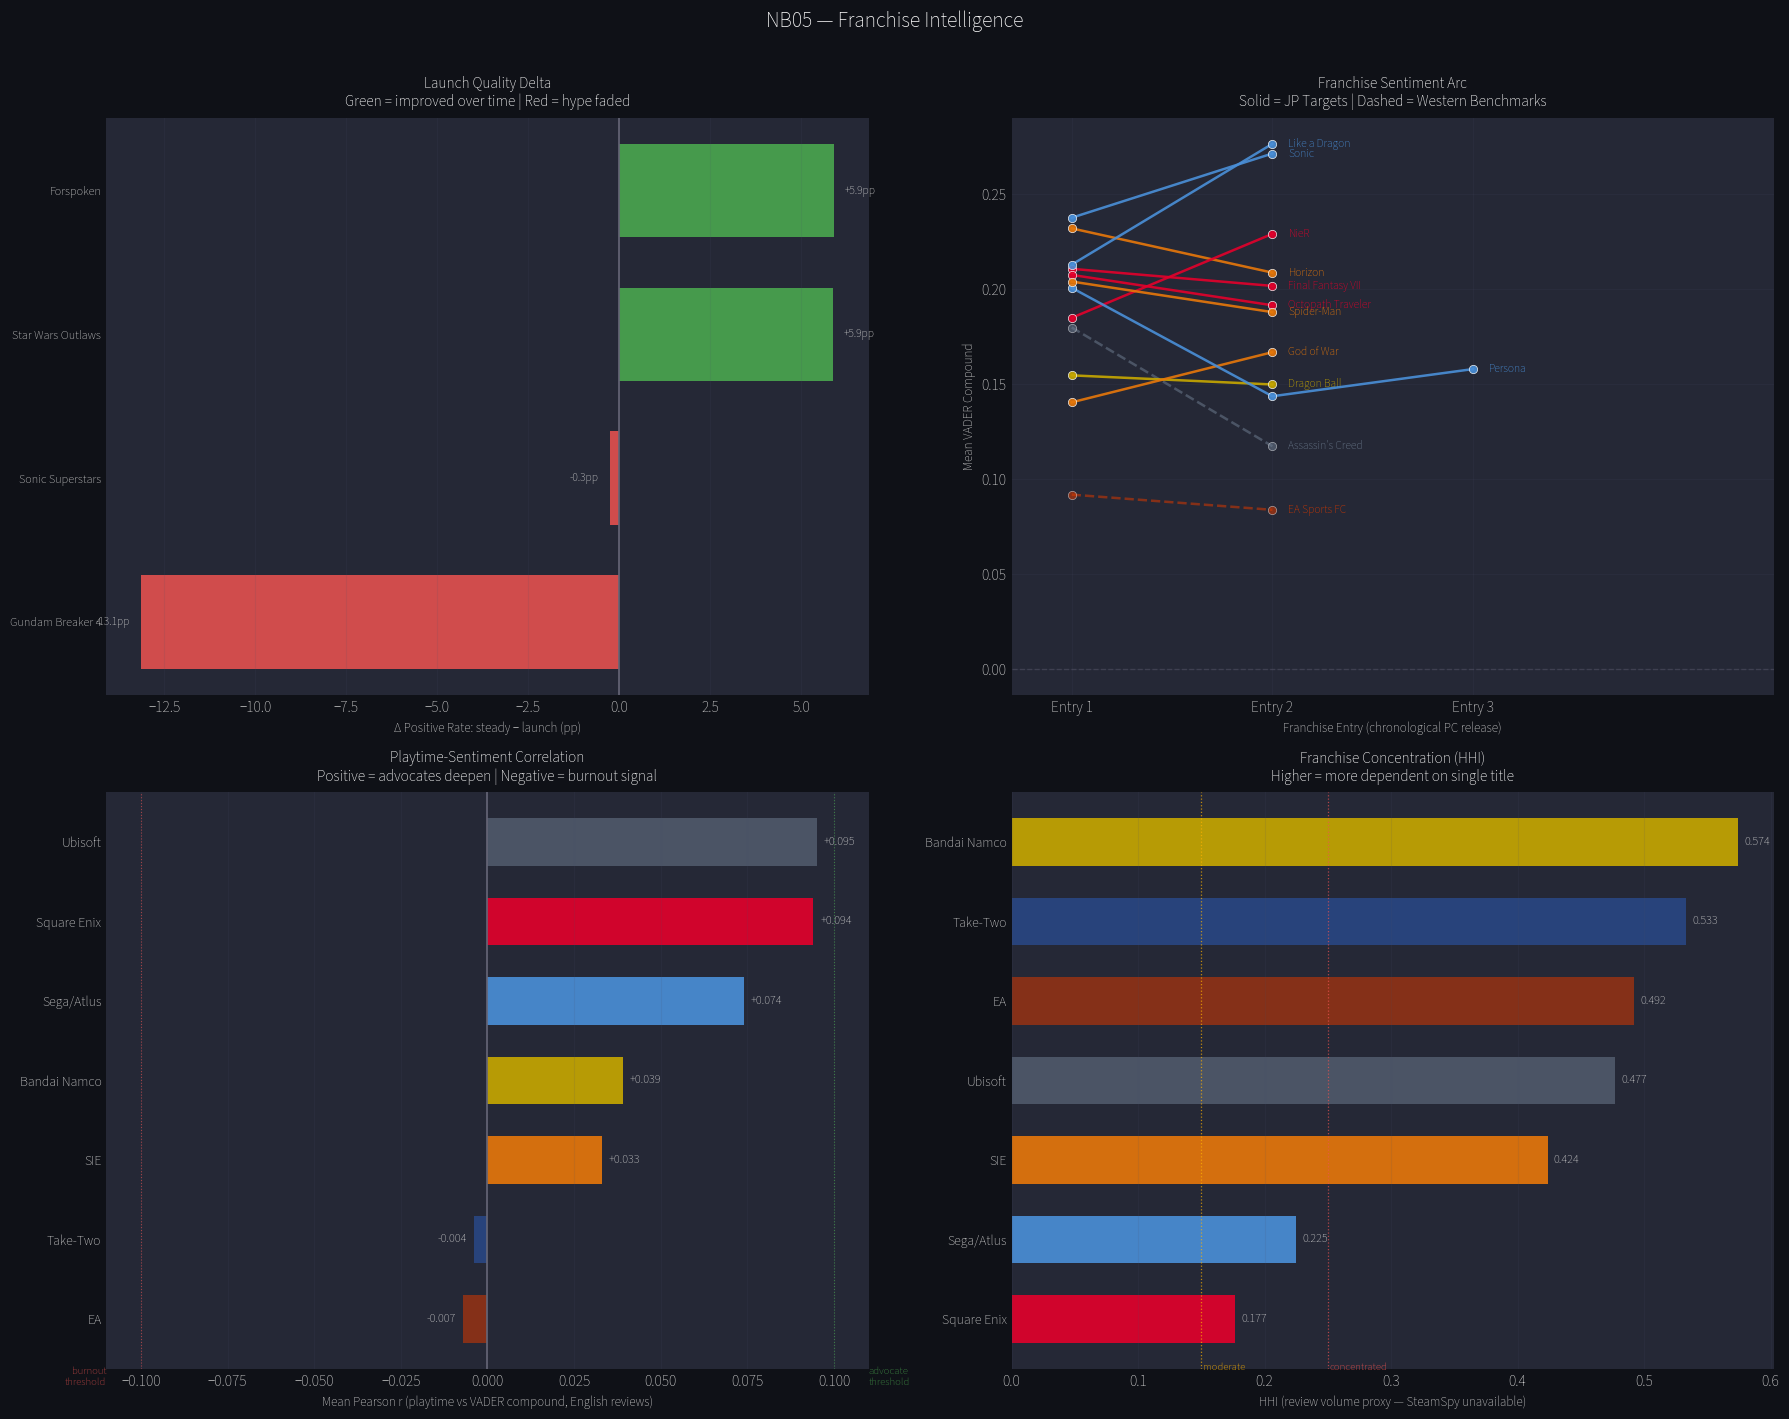

Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB05_franchise_chart.png


In [8]:
# ── CELL 8: Visualization — 4-panel Franchise Chart ───────────────
# Panel TL : Launch Quality Delta (diverging horizontal bar)
# Panel TR : Franchise Fatigue (slope/connected dot chart)
# Panel BL : Playtime-Sentiment by publisher (bar)
# Panel BR : Review Volume HHI (bar)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('NB05 — Franchise Intelligence',
             fontsize=14, fontweight='bold', color='white', y=1.01)

# ── Panel TL: Launch Quality Delta ───────────────────────────────
ax = axes[0, 0]
ax.set_facecolor('#252836')

# Show top 6 recoveries + top 6 fades, sorted by delta
top_n = 6
ld_plot = pd.concat([
    launch_df.head(top_n),
    launch_df.tail(top_n)
]).drop_duplicates('title').sort_values('launch_delta')

colors_ld = [
    ('#4CAF50' if v >= 0 else '#EF5350')
    for v in ld_plot['launch_delta']
]
# Shorten long titles for display
short_titles = [
    t[:28] + '…' if len(t) > 28 else t
    for t in ld_plot['title']
]

bars = ax.barh(short_titles, ld_plot['launch_delta'] * 100,
               color=colors_ld, alpha=0.85, height=0.65, edgecolor='none')

for bar, val in zip(bars, ld_plot['launch_delta'] * 100):
    x_pos = val + (0.3 if val >= 0 else -0.3)
    ha    = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.1f}pp', va='center', ha=ha, fontsize=7.5,
            color='#CCCCCC', fontweight='bold')

ax.axvline(0, color='#666677', linewidth=1.2, zorder=5)
ax.set_xlabel('Δ Positive Rate: steady − launch (pp)', color='#CCCCCC', fontsize=8.5)
ax.set_title('Launch Quality Delta\nGreen = improved over time | Red = hype faded',
             color='white', fontsize=10, pad=8)
ax.grid(axis='x', alpha=0.12, color='#4A5068')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.tick_params(length=0)
ax.set_yticks(range(len(short_titles)))
ax.set_yticklabels(short_titles, color='#CCCCCC', fontsize=8)

# ── Panel TR: Franchise Fatigue ───────────────────────────────────
ax2 = axes[0, 1]
ax2.set_facecolor('#252836')

# Plot each franchise as a connected line
# Separate JP and Western with different line styles
jp_franchises = [
    f for f, grp in fatigue_df.groupby('franchise')
    if grp.iloc[0]['publisher_group'] in JP_TARGETS
]
west_franchises = [
    f for f, grp in fatigue_df.groupby('franchise')
    if grp.iloc[0]['publisher_group'] in WESTERN
]

for franchise, grp in fatigue_df.groupby('franchise'):
    grp = grp.sort_values('seq_idx')
    pub  = grp.iloc[0]['publisher_group']
    color = PUBLISHER_COLORS.get(pub, '#555555')
    ls    = '-' if pub in JP_TARGETS else '--'
    alpha = 0.9 if pub in JP_TARGETS else 0.55

    xs = grp['seq_idx'].values
    ys = grp['mean_compound'].values

    ax2.plot(xs, ys, color=color, linewidth=1.8,
             linestyle=ls, alpha=alpha, marker='o',
             markersize=6, markeredgecolor='white',
             markeredgewidth=0.5, zorder=3)

    # Label the last point with franchise name
    ax2.annotate(
        franchise,
        xy=(xs[-1], ys[-1]),
        xytext=(xs[-1] + 0.08, ys[-1]),
        fontsize=7.5, color=color,
        fontweight='bold' if pub in JP_TARGETS else 'normal',
        va='center',
    )

ax2.axhline(0, color='#555566', linewidth=1.0, linestyle='--', alpha=0.5)
ax2.set_xlabel('Franchise Entry (chronological PC release)', color='#CCCCCC', fontsize=8.5)
ax2.set_ylabel('Mean VADER Compound', color='#CCCCCC', fontsize=8.5)
ax2.set_title('Franchise Sentiment Arc\nSolid = JP Targets | Dashed = Western Benchmarks',
             color='white', fontsize=10, pad=8)
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Entry 1', 'Entry 2', 'Entry 3'], color='#CCCCCC')
ax2.grid(alpha=0.12, color='#4A5068')
ax2.spines[['top','right','left','bottom']].set_visible(False)
ax2.tick_params(length=0)
# Limit x-axis with room for labels
ax2.set_xlim(-0.3, 3.5)

# ── Panel BL: Playtime-Sentiment by Publisher ─────────────────────
ax3 = axes[1, 0]
ax3.set_facecolor('#252836')

pt_plot = pub_playtime.reset_index()
pt_plot['display_name'] = pt_plot['publisher_group'].map(DISPLAY_NAMES)
pt_plot = pt_plot.sort_values('mean_r')

bar_colors = [PUBLISHER_COLORS.get(p, '#555') for p in pt_plot['publisher_group']]
bar_alphas = [0.9 if p in JP_TARGETS else 0.55 for p in pt_plot['publisher_group']]

for i, (_, row) in enumerate(pt_plot.iterrows()):
    ax3.barh(row['display_name'], row['mean_r'],
             color=PUBLISHER_COLORS.get(row['publisher_group'], '#555'),
             alpha=(0.9 if row['publisher_group'] in JP_TARGETS else 0.55),
             height=0.6, edgecolor='none')
    ax3.text(
        row['mean_r'] + (0.002 if row['mean_r'] >= 0 else -0.002),
        i,
        f'{row["mean_r"]:+.3f}',
        va='center',
        ha='left' if row['mean_r'] >= 0 else 'right',
        fontsize=8, color='#CCCCCC', fontweight='bold'
    )

ax3.axvline(0, color='#666677', linewidth=1.2)
ax3.axvline( 0.10, color='#4CAF50', linewidth=0.8, linestyle=':', alpha=0.6)
ax3.axvline(-0.10, color='#EF5350', linewidth=0.8, linestyle=':', alpha=0.6)
ax3.text(0.11, -0.6, 'advocate\nthreshold', color='#4CAF50',
         fontsize=7, va='top', alpha=0.8)
ax3.text(-0.11, -0.6, 'burnout\nthreshold', color='#EF5350',
         fontsize=7, va='top', ha='right', alpha=0.8)

ax3.set_xlabel('Mean Pearson r (playtime vs VADER compound, English reviews)',
               color='#CCCCCC', fontsize=8.5)
ax3.set_title('Playtime-Sentiment Correlation\nPositive = advocates deepen | Negative = burnout signal',
             color='white', fontsize=10, pad=8)
ax3.grid(axis='x', alpha=0.12, color='#4A5068')
ax3.spines[['top','right','left','bottom']].set_visible(False)
ax3.tick_params(length=0)
ax3.tick_params(axis='y', labelcolor='#CCCCCC', labelsize=9)

# ── Panel BR: HHI ─────────────────────────────────────────────────
ax4 = axes[1, 1]
ax4.set_facecolor('#252836')

hhi_plot = hhi_df.sort_values('hhi')

for i, (_, row) in enumerate(hhi_plot.iterrows()):
    color = PUBLISHER_COLORS.get(row['publisher_group'], '#555')
    alpha = 0.9 if row['publisher_group'] in JP_TARGETS else 0.55
    ax4.barh(row['display_name'], row['hhi'],
             color=color, alpha=alpha, height=0.6, edgecolor='none')
    ax4.text(
        row['hhi'] + 0.005, i,
        f"{row['hhi']:.3f}",
        va='center', ha='left', fontsize=8,
        color='#CCCCCC', fontweight='bold'
    )

# Concentration threshold lines
ax4.axvline(0.15, color='#FFB300', linewidth=0.9, linestyle=':', alpha=0.7)
ax4.axvline(0.25, color='#EF5350', linewidth=0.9, linestyle=':', alpha=0.7)
ax4.text(0.151, -0.55, 'moderate', color='#FFB300', fontsize=7, va='top')
ax4.text(0.251, -0.55, 'concentrated', color='#EF5350', fontsize=7, va='top')

ax4.set_xlabel('HHI (review volume proxy — SteamSpy unavailable)',
               color='#CCCCCC', fontsize=8.5)
ax4.set_title('Franchise Concentration (HHI)\nHigher = more dependent on single title',
             color='white', fontsize=10, pad=8)
ax4.grid(axis='x', alpha=0.12, color='#4A5068')
ax4.spines[['top','right','left','bottom']].set_visible(False)
ax4.tick_params(length=0)
ax4.tick_params(axis='y', labelcolor='#CCCCCC', labelsize=9)

plt.tight_layout()
out1 = PROCESSED / 'NB05_franchise_chart.png'
plt.savefig(out1, dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'Saved: {out1}')


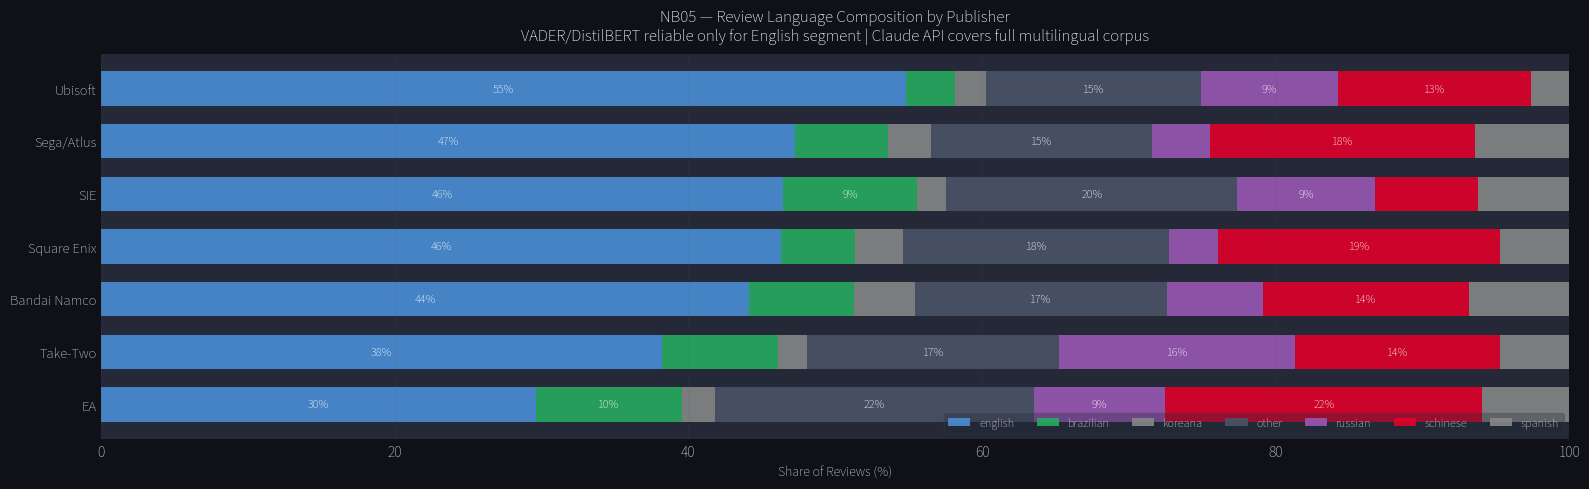

Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB05_language_chart.png


In [9]:
# ── CELL 9: Visualization — Language Distribution ─────────────────
# Stacked horizontal bar — normalized to 100% per publisher
# Shows language composition across publishers

# Build stacked data: top 6 languages + 'other'
TOP_N_LANGS = 6

pub_lang_raw = (
    vader_df.groupby(['publisher_group', 'language'])
    .size()
    .reset_index(name='count')
)

# Find top languages globally
top_langs = (
    pub_lang_raw.groupby('language')['count']
    .sum()
    .nlargest(TOP_N_LANGS)
    .index.tolist()
)

# Remap non-top to 'other'
pub_lang_raw['lang_group'] = pub_lang_raw['language'].where(
    pub_lang_raw['language'].isin(top_langs), 'other'
)
stacked = (
    pub_lang_raw.groupby(['publisher_group', 'lang_group'])['count']
    .sum()
    .unstack(fill_value=0)
)
# Normalize to 100%
stacked_pct = stacked.div(stacked.sum(axis=1), axis=0) * 100
stacked_pct.index = [DISPLAY_NAMES.get(p, p) for p in stacked_pct.index]
stacked_pct = stacked_pct.sort_values('english', ascending=True)

# Colour map for languages
LANG_COLORS = {
    'english':    '#4A90D9',
    'schinese':   '#E4002B',
    'russian':    '#9B59B6',
    'brazilian':  '#27AE60',
    'japanese':   '#E8780A',
    'tchinese':   '#C0392B',
    'other':      '#4A5568',
}

fig2, ax5 = plt.subplots(figsize=(16, 5))
fig2.patch.set_facecolor('#0F1117')
ax5.set_facecolor('#252836')

# Order columns: english first, then by total share
col_order = ['english'] + [
    c for c in stacked_pct.columns if c != 'english'
]
col_order = [c for c in col_order if c in stacked_pct.columns]

lefts = np.zeros(len(stacked_pct))
for lang in col_order:
    if lang not in stacked_pct.columns:
        continue
    vals   = stacked_pct[lang].values
    color  = LANG_COLORS.get(lang, '#888888')
    bars   = ax5.barh(
        stacked_pct.index, vals,
        left=lefts, color=color,
        alpha=0.88, height=0.65,
        edgecolor='none', label=lang
    )
    # Label segments >8%
    for bar, val, left in zip(bars, vals, lefts):
        if val >= 8:
            ax5.text(
                left + val / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%',
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold'
            )
    lefts += vals

ax5.set_xlim(0, 100)
ax5.set_xlabel('Share of Reviews (%)', color='#CCCCCC', fontsize=9)
ax5.set_title(
    'NB05 — Review Language Composition by Publisher\n'
    'VADER/DistilBERT reliable only for English segment'
    ' | Claude API covers full multilingual corpus',
    color='white', fontsize=11, pad=10
)
ax5.grid(axis='x', alpha=0.1, color='#4A5068')
ax5.spines[['top','right','left','bottom']].set_visible(False)
ax5.tick_params(length=0)
ax5.tick_params(axis='y', labelcolor='#CCCCCC', labelsize=9.5)
ax5.legend(
    loc='lower right', fontsize=8,
    labelcolor='#CCCCCC', framealpha=0.3,
    ncol=len(col_order)
)

plt.tight_layout()
out2 = PROCESSED / 'NB05_language_chart.png'
plt.savefig(out2, dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'Saved: {out2}')


In [10]:
# ── CELL 10: Save outputs ─────────────────────────────────────────
# All DataFrames already saved to cache during computation.
# This cell confirms all outputs exist.

outputs = [
    PROCESSED / 'NB05_timestamps.csv',
    PROCESSED / 'NB05_launch_delta.csv',
    PROCESSED / 'NB05_playtime_sentiment.csv',
    PROCESSED / 'NB05_franchise_fatigue.csv',
    PROCESSED / 'NB05_language_dist.csv',
    PROCESSED / 'NB05_hhi.csv',
    PROCESSED / 'NB05_franchise_chart.png',
    PROCESSED / 'NB05_language_chart.png',
]

print('── NB05 Output Manifest ──────────────────────────────────────')
for p in outputs:
    status = '✓' if p.exists() else '✗ MISSING'
    size   = f'{p.stat().st_size/1024:.1f}KB' if p.exists() else '—'
    print(f'  {status}  {p.name:45s} {size}')


── NB05 Output Manifest ──────────────────────────────────────
  ✓  NB05_timestamps.csv                           4934.6KB
  ✓  NB05_launch_delta.csv                         0.3KB
  ✓  NB05_playtime_sentiment.csv                   3.0KB
  ✓  NB05_franchise_fatigue.csv                    1.9KB
  ✓  NB05_language_dist.csv                        55.2KB
  ✓  NB05_hhi.csv                                  0.5KB
  ✓  NB05_franchise_chart.png                      237.6KB
  ✓  NB05_language_chart.png                       72.8KB


In [11]:
# ── CELL 11: NB05 Observation ────────────────────────────────────

# Best recovery and worst fade
best_recovery  = launch_df.iloc[0]
worst_fade     = launch_df.iloc[-1]

# Best / worst playtime-sentiment
best_deepener  = playtime_df.iloc[0]
worst_burnout  = playtime_df.iloc[-1]

# Franchise arcs
best_arc   = delta_df.iloc[0]
worst_arc  = delta_df.iloc[-1]

# HHI
most_concentrated   = hhi_df.iloc[0]
most_diversified    = hhi_df.iloc[-1]

# Language
most_global = eng_by_title.loc[eng_by_title['english_pct'].idxmax()]
most_jp     = eng_filtered.loc[eng_filtered['english_pct'].idxmin()]

# Publisher with highest share of recovering titles
pub_rec = pub_launch.sort_values('mean_delta', ascending=False)
top_recovery_pub = DISPLAY_NAMES.get(pub_rec.index[0], pub_rec.index[0])

print(f"""
NB05 Observation
─────────────────────────────────────────────────────
Block 1 — Launch Quality Delta
  Best recovery  : {best_recovery['title']} ({best_recovery['launch_delta']:+.3f})
                   launched at {best_recovery['launch_pos_rate']*100:.1f}%, \
settled at {best_recovery['steady_pos_rate']*100:.1f}%
  Worst fade     : {worst_fade['title']} ({worst_fade['launch_delta']:+.3f})
                   launched at {worst_fade['launch_pos_rate']*100:.1f}%, \
settled at {worst_fade['steady_pos_rate']*100:.1f}%
  Publisher with most recoveries: {top_recovery_pub}
  Caveat: Steam cursor returns newest-first — launch window may be
          undersampled for older/high-volume titles. Flag for NB07.

Block 2 — Playtime-Sentiment Correlation
  Strongest deepener : {best_deepener['title']} (r={best_deepener['playtime_r']:+.3f})
  Strongest burnout  : {worst_burnout['title']} (r={worst_burnout['playtime_r']:+.3f})
  Publishers with deepen signal: \
{', '.join(DISPLAY_NAMES.get(p, p) for p in pub_playtime[pub_playtime['n_deepen']>0].index)}

Block 3 — Franchise Fatigue
  Best arc  : {best_arc['franchise']} \
({best_arc['first_compound']:+.3f} → {best_arc['last_compound']:+.3f}, \
Δ={best_arc['fatigue_delta']:+.3f})
  Worst arc : {worst_arc['franchise']} \
({worst_arc['first_compound']:+.3f} → {worst_arc['last_compound']:+.3f}, \
Δ={worst_arc['fatigue_delta']:+.3f})
  Finding: Franchise trajectory is a leading indicator of publisher
           health — declining arcs precede IR-visible revenue erosion.

Block 4 — Language Distribution
  Most globalised title : {most_global['title']} \
({most_global['english_pct']:.1f}% English)
  Most JP-concentrated  : {most_jp['title']} \
({most_jp['english_pct']:.1f}% English)
  Implication: Publishers with JP-concentrated corpora see VADER/
               DistilBERT scores most diluted — Block 3 Claude API
               is essential, not optional, for these titles.

Block 5 — Review Volume HHI
  Most concentrated  : \
{DISPLAY_NAMES.get(most_concentrated['publisher_group'], most_concentrated['publisher_group'])} \
(HHI={most_concentrated['hhi']:.3f}, driven by {most_concentrated['top_title']})
  Most diversified   : \
{DISPLAY_NAMES.get(most_diversified['publisher_group'], most_diversified['publisher_group'])} \
(HHI={most_diversified['hhi']:.3f})
  Caveat: SteamSpy ownership unavailable — review count used as
          proxy. Niche/JP titles underrepresented vs install base.

Next: NB06 — Predictive Model
""")



NB05 Observation
─────────────────────────────────────────────────────
Block 1 — Launch Quality Delta
  Best recovery  : Forspoken (+0.059)
                   launched at 64.9%, settled at 70.8%
  Worst fade     : Gundam Breaker 4 (-0.131)
                   launched at 77.6%, settled at 64.5%
  Publisher with most recoveries: Square Enix
  Caveat: Steam cursor returns newest-first — launch window may be
          undersampled for older/high-volume titles. Flag for NB07.

Block 2 — Playtime-Sentiment Correlation
  Strongest deepener : Forspoken (r=+0.186)
  Strongest burnout  : Tekken 8 (r=-0.080)
  Publishers with deepen signal: Ubisoft, Square Enix, Sega/Atlus, Bandai Namco, SIE

Block 3 — Franchise Fatigue
  Best arc  : Like a Dragon (+0.213 → +0.276, Δ=+0.064)
  Worst arc : Assassin's Creed (+0.180 → +0.117, Δ=-0.062)
  Finding: Franchise trajectory is a leading indicator of publisher
           health — declining arcs precede IR-visible revenue erosion.

Block 4 — Language Distri